# Задание 3: Построение сложной модели с подбором гиперпараметров и интерпретация

В этом ноутбуке мы:
1. Построим ансамблевые модели (Random Forest, XGBoost, LightGBM, CatBoost)
2. Подберем оптимальные гиперпараметры с помощью Optuna (TPE-сэмплер)
3. Обучим лучшую модель и оценим ее качество
4. Проведем глобальную и локальную интерпретацию модели
5. Дадим экспертное заключение о результатах


In [137]:
# Установка нужных библиотек
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost shap lime optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Импорт библиотек

Импортируем необходимые библиотеки для работы с данными, моделями и визуализации.


In [138]:
import warnings
from dataclasses import dataclass
from pathlib import Path
from time import time
from typing import Any, Callable, Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from lime import lime_tabular
from matplotlib.patches import Patch
from optuna.samplers import TPESampler
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


In [139]:
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 0. Настройки и вспомогательные функции

Чтобы не дублировать технический код (очистка данных, подготовка призаков, единый шаблон Optuna), вынесем его в отдельный блок и будем переиспользовать дальше по всему ноутбуку.


In [140]:
# Фиксируем random_state для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Random state зафиксирован: {RANDOM_STATE}")

Random state зафиксирован: 42


In [141]:
DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [142]:
@dataclass
class SearchResult:
    model_name: str
    best_score: float
    best_params: Dict[str, Any]
    elapsed: float
    estimator: Any

In [143]:
def load_dataset(path: Path) -> Tuple[pd.DataFrame, int]:
    """Загружает датасет и аккуратно приводит TotalCharges к числу."""
    df = pd.read_csv(path)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    missing_total = df["TotalCharges"].isna().sum()
    if missing_total:
        df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
    return df, missing_total


def prepare_data(df: pd.DataFrame, test_size: float = 0.2):
    """Полный цикл подготовки признаков + стратифицированное разбиение."""
    dataset = df.drop(columns="customerID")
    X = dataset.drop(columns="Churn")
    y = dataset["Churn"]

    # Находим числовые признаки до кодирования (как в HW2)
    original_numeric_cols = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    print(
        f"Исходные числовые признаки (будут стандартизированы): {original_numeric_cols}"
    )

    y_encoder = LabelEncoder()
    y_encoded = y_encoder.fit_transform(y)

    categorical_columns = X.select_dtypes(include="object").columns.tolist()
    X_encoded = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True,
        dtype=int,
    )

    numeric_cols = [col for col in original_numeric_cols if col in X_encoded.columns]

    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded,
        y_encoded,
        test_size=test_size,
        stratify=y_encoded,
        random_state=RANDOM_STATE,
    )

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if numeric_cols:
        X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    info = {
        "feature_names": X_encoded.columns.tolist(),
        "numeric_cols": numeric_cols,
        "class_distribution": np.bincount(y_encoded),
    }

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        y_encoder,
        info,
    )


def run_optuna_search(
    model_name: str,
    estimator,
    param_sampler: Callable[[optuna.trial.Trial], Dict[str, Any]],
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    cv: StratifiedKFold,
    n_trials: int = 50,
) -> SearchResult:
    """Унифицированный раннер Optuna c TPE-сэмплером."""

    def objective(trial: optuna.trial.Trial) -> float:
        params = param_sampler(trial)
        model = clone(estimator)
        model.set_params(**params)
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="f1",
            n_jobs=-1,
        )
        return scores.mean()

    sampler = TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(
        study_name=f"{model_name}_optuna",
        direction="maximize",
        sampler=sampler,
    )

    start = time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    elapsed = time() - start

    best_model = clone(estimator)
    best_model.set_params(**study.best_params)
    best_model.fit(X_train, y_train)

    return SearchResult(
        model_name=model_name,
        best_score=study.best_value,
        best_params=study.best_params,
        elapsed=elapsed,
        estimator=best_model,
    )


## 2. Загрузка и предобработка данных

Загружаем датасет Telco Customer Churn и применяем те же методы предобработки, что и в предыдущих заданиях для обеспечения сопоставимости результатов.


In [144]:
# Загрузка данных и приведение TotalCharges к числу

df, totalcharges_missing = load_dataset(DATA_PATH)

print(f"Размер датасета: {df.shape}")
print(f"Количество пропусков после очистки: {df.isnull().sum().sum()}")
if totalcharges_missing:
    print(
        f"TotalCharges: перевели в float и заполнили {totalcharges_missing} пропусков медианой"
    )

df.head()


Размер датасета: (7043, 21)
Количество пропусков после очистки: 0
TotalCharges: перевели в float и заполнили 11 пропусков медианой


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1. Обоснование методов предобработки

**Применяемые методы:**

1. **Удаление customerID**: идентификатор не несет предсказательной информации
2. **One-Hot Encoding**: кодирование категориальных признаков с `drop_first=True` для избежания мультиколлинеарности
3. **StandardScaler**: масштабирование только числовых признаков (tenure, MonthlyCharges, TotalCharges), чтобы не искажать бинарные признаки
4. **Stratified split**: сохранение пропорций классов при разбиении (важно из-за дисбаланса 73.5%/26.5%)



In [145]:
# Предобработка и разбиение выполняем через вспомогательную функцию
(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    y_encoder,
    data_info,
) = prepare_data(df)

feature_names = data_info["feature_names"]
numeric_cols = data_info["numeric_cols"]
dataset_size = len(df)

print(f"Признаков после кодирования: {len(feature_names)}")
print(f"Числовых признаков для масштабирования: {len(numeric_cols)}")
print(
    f"Train/Test: {X_train_scaled.shape[0]} / {X_test_scaled.shape[0]} "
    f"({X_train_scaled.shape[0] / dataset_size * 100:.1f}% / "
    f"{X_test_scaled.shape[0] / dataset_size * 100:.1f}%)"
)

class_distribution = (
    pd.Series(data_info["class_distribution"], index=y_encoder.classes_)
    .rename("Количество")
    .to_frame()
)
class_distribution["Доля"] = (
    class_distribution["Количество"] / class_distribution["Количество"].sum()
)
class_distribution


Исходные числовые признаки (будут стандартизированы): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Признаков после кодирования: 30
Числовых признаков для масштабирования: 4
Train/Test: 5634 / 1409 (80.0% / 20.0%)


,Количество,Доля
No,5174,0.73463
Yes,1869,0.26537


## 3. Выбор ансамблевх моделей и подбор гиперпараметров

### 3.1. Обоснование выбора моделей

Используем четыре современные ансамблевые модели:

1. **Random Forest** - базовый ансамбль деревьев с бэггингом
2. **XGBoost** - градиентный бустинг с регуляризацией
3. **LightGBM** - быстрый градиентный бустинг
4. **CatBoost** - бустинг с оптимизацией для категориальных признаков

**Метод подбора**: Optuna (TPE) + 5-fold стратифицированная кросс-валидация
- Более эффективен чем GridSearch для больших пространств параметров
- Stratified K-Fold сохраняет пропорции классов в каждом fold
- Метрика оптимизации: F1-score (из-за дисбаланса классов)


### 3.2. Определение пространств гиперпараметров

**Random Forest:**
- `n_estimators`: количество деревьев (100-500)
- `max_depth`: глубина дерева (10-50)
- `min_samples_split`: минимум объектов для разбиения (2-10)
- `min_samples_leaf`: минимум объектов в листе (1-4)
- `class_weight`: работа с дисбалансом (balanced/None)

**XGBoost:**
- `n_estimators`: количество итераций (100-500)
- `max_depth`: глубина дерева (3-10)
- `learning_rate`: шаг обучения (0.01-0.3)
- `subsample`: доля объектов для обучения (0.7-1.0)
- `colsample_bytree`: доля признаков (0.7-1.0)
- `scale_pos_weight`: вес положительного класса для дисбаланса

**LightGBM:**
- Аналогично XGBoost + `num_leaves` вместо `max_depth`
- `is_unbalance`: автоматическая работа с дисбалансом

**CatBoost:**
- Аналогично XGBoost + специфичные параметры (`depth`, `l2_leaf_reg`)


In [146]:
# Определяем пространства гиперпараметров для каждой модели (Optuna)
# Добавил параметры регуляризации (по экспериментами с ними было качество лучше)


def rf_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_categorical("max_depth", [10, 20, 30, 40, 50, None]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "min_weight_fraction_leaf": trial.suggest_float(
            "min_weight_fraction_leaf", 0.0, 0.1
        ),
        "max_leaf_nodes": trial.suggest_categorical(
            "max_leaf_nodes", [None, 50, 100, 200]
        ),
    }


def xgb_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }


def lgbm_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "num_leaves": trial.suggest_int("num_leaves", 20, 60),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "is_unbalance": trial.suggest_categorical("is_unbalance", [True, False]),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 1.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 10.0),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 1.0),
    }


def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
    }


In [147]:
# Настройка кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Словарь моделей и их sampler-функций для Optuna
models_params = {
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        rf_param_space,
    ),
    "XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"),
        xgb_param_space,
    ),
    "LightGBM": (
        LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        lgbm_param_space,
    ),
    "CatBoost": (
        CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
        catboost_param_space,
    ),
}

print(f"Будет проведен подбор гиперпараметров для {len(models_params)} моделей")
print("Это может занять несколько минут...")


Будет проведен подбор гиперпараметров для 4 моделей
Это может занять несколько минут...


In [148]:
# Подбор гиперпараметров для каждой модели
best_models = {}
search_results = []

for model_name, (model, param_sampler) in models_params.items():
    print(f"\n{'=' * 70}")
    print(f"Подбор гиперпараметров для: {model_name}")
    print(f"{'=' * 70}")

    result = run_optuna_search(
        model_name=model_name,
        estimator=model,
        param_sampler=param_sampler,
        X_train=X_train_scaled,
        y_train=y_train,
        cv=cv,
        n_trials=50,
    )

    best_models[model_name] = result.estimator
    search_results.append(
        {
            "Model": result.model_name,
            "Best CV F1-Score": result.best_score,
            "Best Params": result.best_params,
            "Time (sec)": result.elapsed,
        }
    )

    print(f"\nЛучший F1-score (CV): {result.best_score:.4f}")
    print(f"Время выполнения: {result.elapsed:.2f} сек")
    print(f"Лучшие параметры: {result.best_params}")

print(f"\n{'=' * 70}")
print("Подбор гиперпараметров завершен!")
print(f"{'=' * 70}")

[I 2025-11-23 19:36:22,423] A new study created in memory with name: Random Forest_optuna



Подбор гиперпараметров для: Random Forest


[I 2025-11-23 19:36:28,693] Trial 0 finished with value: 0.6292877218981064 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced', 'min_weight_fraction_leaf': 0.021233911067827616, 'max_leaf_nodes': 200}. Best is trial 0 with value: 0.6292877218981064.
[I 2025-11-23 19:36:32,423] Trial 1 finished with value: 0.5262130750175034 and parameters: {'n_estimators': 273, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'min_weight_fraction_leaf': 0.017052412368729154, 'max_leaf_nodes': 100}. Best is trial 0 with value: 0.6292877218981064.
[I 2025-11-23 19:36:33,564] Trial 2 finished with value: 0.5388632502483307 and parameters: {'n_estimators': 222, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None, 'min_weight_fraction_leaf': 0.018485445552552705, 'max_leaf_nodes': None}. Be


Лучший F1-score (CV): 0.6411
Время выполнения: 126.14 сек
Лучшие параметры: {'n_estimators': 319, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced', 'min_weight_fraction_leaf': 0.000556089703257311, 'max_leaf_nodes': 100}

Подбор гиперпараметров для: XGBoost


[I 2025-11-23 19:38:31,162] Trial 0 finished with value: 0.6199960744728084 and parameters: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.1205712628744377, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'scale_pos_weight': 1.3119890406724053, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 8.795585311974417, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.6199960744728084.
[I 2025-11-23 19:38:32,055] Trial 1 finished with value: 0.6216946233580163 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7637017332034828, 'scale_pos_weight': 1.3636499344142012, 'reg_alpha': 0.18340450985343382, 'reg_lambda': 3.7381801866358395, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.6216946233580163.
[I 2025-11-23 19:38:32,762] Trial 2 finished with value: 0.6209908973078733 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.0


Лучший F1-score (CV): 0.6385
Время выполнения: 45.66 сек
Лучшие параметры: {'n_estimators': 476, 'max_depth': 3, 'learning_rate': 0.02870988831692176, 'subsample': 0.8149696503837726, 'colsample_bytree': 0.8582318892087445, 'scale_pos_weight': 2.2203534877262645, 'reg_alpha': 0.0020019815160440737, 'reg_lambda': 6.593268103753602, 'gamma': 0.23334768304594444}

Подбор гиперпараметров для: LightGBM


[I 2025-11-23 19:39:17,235] Trial 0 finished with value: 0.6314785383632042 and parameters: {'n_estimators': 250, 'num_leaves': 58, 'learning_rate': 0.08960785365368121, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'is_unbalance': True, 'lambda_l1': 0.8661761457749352, 'lambda_l2': 6.011150117432088, 'min_gain_to_split': 0.7080725777960455}. Best is trial 0 with value: 0.6314785383632042.
[I 2025-11-23 19:39:18,400] Trial 1 finished with value: 0.5835853313801798 and parameters: {'n_estimators': 108, 'num_leaves': 59, 'learning_rate': 0.12106896936002161, 'subsample': 0.7637017332034828, 'colsample_bytree': 0.7545474901621302, 'is_unbalance': False, 'lambda_l1': 0.5247564316322378, 'lambda_l2': 4.319450186421157, 'min_gain_to_split': 0.2912291401980419}. Best is trial 0 with value: 0.6314785383632042.
[I 2025-11-23 19:39:21,160] Trial 2 finished with value: 0.6281357245405337 and parameters: {'n_estimators': 345, 'num_leaves': 25, 'learning_rate': 0.02399324


Лучший F1-score (CV): 0.6367
Время выполнения: 74.79 сек
Лучшие параметры: {'n_estimators': 105, 'num_leaves': 32, 'learning_rate': 0.018028040701636664, 'subsample': 0.8357628015789288, 'colsample_bytree': 0.7048062486661252, 'is_unbalance': True, 'lambda_l1': 0.9794255917727445, 'lambda_l2': 7.965019059223769, 'min_gain_to_split': 0.5995018382569194}

Подбор гиперпараметров для: CatBoost


[I 2025-11-23 19:40:47,236] Trial 0 finished with value: 0.5475946527706197 and parameters: {'iterations': 250, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 6.387926357773329, 'random_strength': 1.5601864044243652, 'bagging_temperature': 0.15599452033620265}. Best is trial 0 with value: 0.5475946527706197.
[I 2025-11-23 19:40:56,839] Trial 1 finished with value: 0.5673245684952395 and parameters: {'iterations': 123, 'depth': 10, 'learning_rate': 0.06054365855469246, 'l2_leaf_reg': 7.372653200164409, 'random_strength': 0.20584494295802447, 'bagging_temperature': 0.9699098521619943}. Best is trial 1 with value: 0.5673245684952395.
[I 2025-11-23 19:41:00,802] Trial 2 finished with value: 0.5863010179364576 and parameters: {'iterations': 433, 'depth': 5, 'learning_rate': 0.017240892195821537, 'l2_leaf_reg': 2.650640588680904, 'random_strength': 3.0424224295953772, 'bagging_temperature': 0.5247564316322378}. Best is trial 2 with value: 0.5863010179364576.
[I 2025-11-23 


Лучший F1-score (CV): 0.5952
Время выполнения: 219.62 сек
Лучшие параметры: {'iterations': 161, 'depth': 4, 'learning_rate': 0.06296677379498765, 'l2_leaf_reg': 5.571802612215683, 'random_strength': 2.7347658105471435, 'bagging_temperature': 0.09929117322425042}

Подбор гиперпараметров завершен!


### 3.4. Сравнение результатов подбора гиперпараметров



РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:
        Model  Best CV F1-Score  Time (sec)
Random Forest          0.641094  126.141976
      XGBoost          0.638460   45.661732
     LightGBM          0.636721   74.790083
     CatBoost          0.595166  219.620148


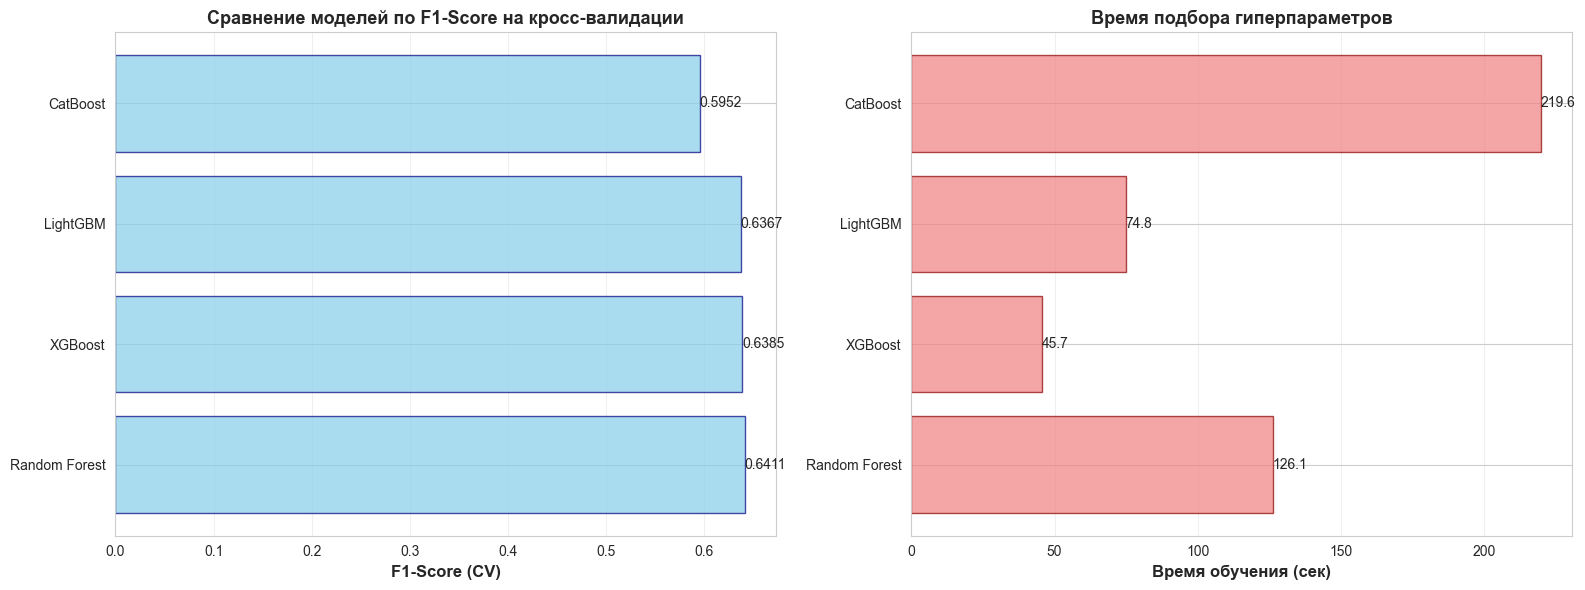

In [149]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame(search_results)
results_df = results_df.sort_values("Best CV F1-Score", ascending=False)

print("\nРЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:")
print(results_df[["Model", "Best CV F1-Score", "Time (sec)"]].to_string(index=False))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График F1-Score
bars1 = ax1.barh(
    results_df["Model"],
    results_df["Best CV F1-Score"],
    color="skyblue",
    edgecolor="navy",
    alpha=0.7,
)
ax1.set_xlabel("F1-Score (CV)", fontsize=12, fontweight="bold")
ax1.set_title(
    "Сравнение моделей по F1-Score на кросс-валидации", fontsize=13, fontweight="bold"
)
ax1.grid(axis="x", alpha=0.3)

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        ha="left",
        va="center",
        fontsize=10,
    )

# График времени обучения
bars2 = ax2.barh(
    results_df["Model"],
    results_df["Time (sec)"],
    color="lightcoral",
    edgecolor="darkred",
    alpha=0.7,
)
ax2.set_xlabel("Время обучения (сек)", fontsize=12, fontweight="bold")
ax2.set_title("Время подбора гиперпараметров", fontsize=13, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="left",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


In [150]:
# Выводим лучшие параметры для каждой модели
print("\nЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ КАЖДОЙ МОДЕЛИ:")
for result in search_results:
    print(f"\n{result['Model']}:")
    for param, value in result["Best Params"].items():
        print(f"  {param}: {value}")



ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ КАЖДОЙ МОДЕЛИ:

Random Forest:
  n_estimators: 319
  max_depth: 20
  min_samples_split: 6
  min_samples_leaf: 1
  max_features: sqrt
  class_weight: balanced
  min_weight_fraction_leaf: 0.000556089703257311
  max_leaf_nodes: 100

XGBoost:
  n_estimators: 476
  max_depth: 3
  learning_rate: 0.02870988831692176
  subsample: 0.8149696503837726
  colsample_bytree: 0.8582318892087445
  scale_pos_weight: 2.2203534877262645
  reg_alpha: 0.0020019815160440737
  reg_lambda: 6.593268103753602
  gamma: 0.23334768304594444

LightGBM:
  n_estimators: 105
  num_leaves: 32
  learning_rate: 0.018028040701636664
  subsample: 0.8357628015789288
  colsample_bytree: 0.7048062486661252
  is_unbalance: True
  lambda_l1: 0.9794255917727445
  lambda_l2: 7.965019059223769
  min_gain_to_split: 0.5995018382569194

CatBoost:
  iterations: 161
  depth: 4
  learning_rate: 0.06296677379498765
  l2_leaf_reg: 5.571802612215683
  random_strength: 2.7347658105471435
  bagging_temperature: 0.0992911

In [151]:
# Функция для оценки модели на тестовой выборке
def evaluate_model_on_test(model, X_test, y_test, model_name):
    """Оценивает качество модели на тестовой выборке."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    return metrics, y_pred, y_proba


# Оценка всех моделей
test_results = []
predictions_dict = {}

print("ОЦЕНКА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:")

for model_name, model in best_models.items():
    metrics, y_pred, y_proba = evaluate_model_on_test(
        model, X_test_scaled, y_test, model_name
    )
    test_results.append(metrics)
    predictions_dict[model_name] = {"y_pred": y_pred, "y_proba": y_proba}

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")

ОЦЕНКА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:

Random Forest:
  Accuracy:  0.7615
  F1-Score:  0.6324
  Precision: 0.5352
  Recall:    0.7727
  ROC-AUC:   0.8449

XGBoost:
  Accuracy:  0.7580
  F1-Score:  0.6257
  Precision: 0.5307
  Recall:    0.7620
  ROC-AUC:   0.8465

LightGBM:
  Accuracy:  0.7651
  F1-Score:  0.6359
  Precision: 0.5402
  Recall:    0.7727
  ROC-AUC:   0.8450

CatBoost:
  Accuracy:  0.8077
  F1-Score:  0.5937
  Precision: 0.6758
  Recall:    0.5294
  ROC-AUC:   0.8487



СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ НА ТЕСТОВОЙ ВЫБОРКЕ:
        Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
     LightGBM  0.765082  0.635864   0.540187 0.772727 0.844995
Random Forest  0.761533  0.632385   0.535185 0.772727 0.844893
      XGBoost  0.757984  0.625686   0.530726 0.762032 0.846503
     CatBoost  0.807665  0.593703   0.675768 0.529412 0.848686


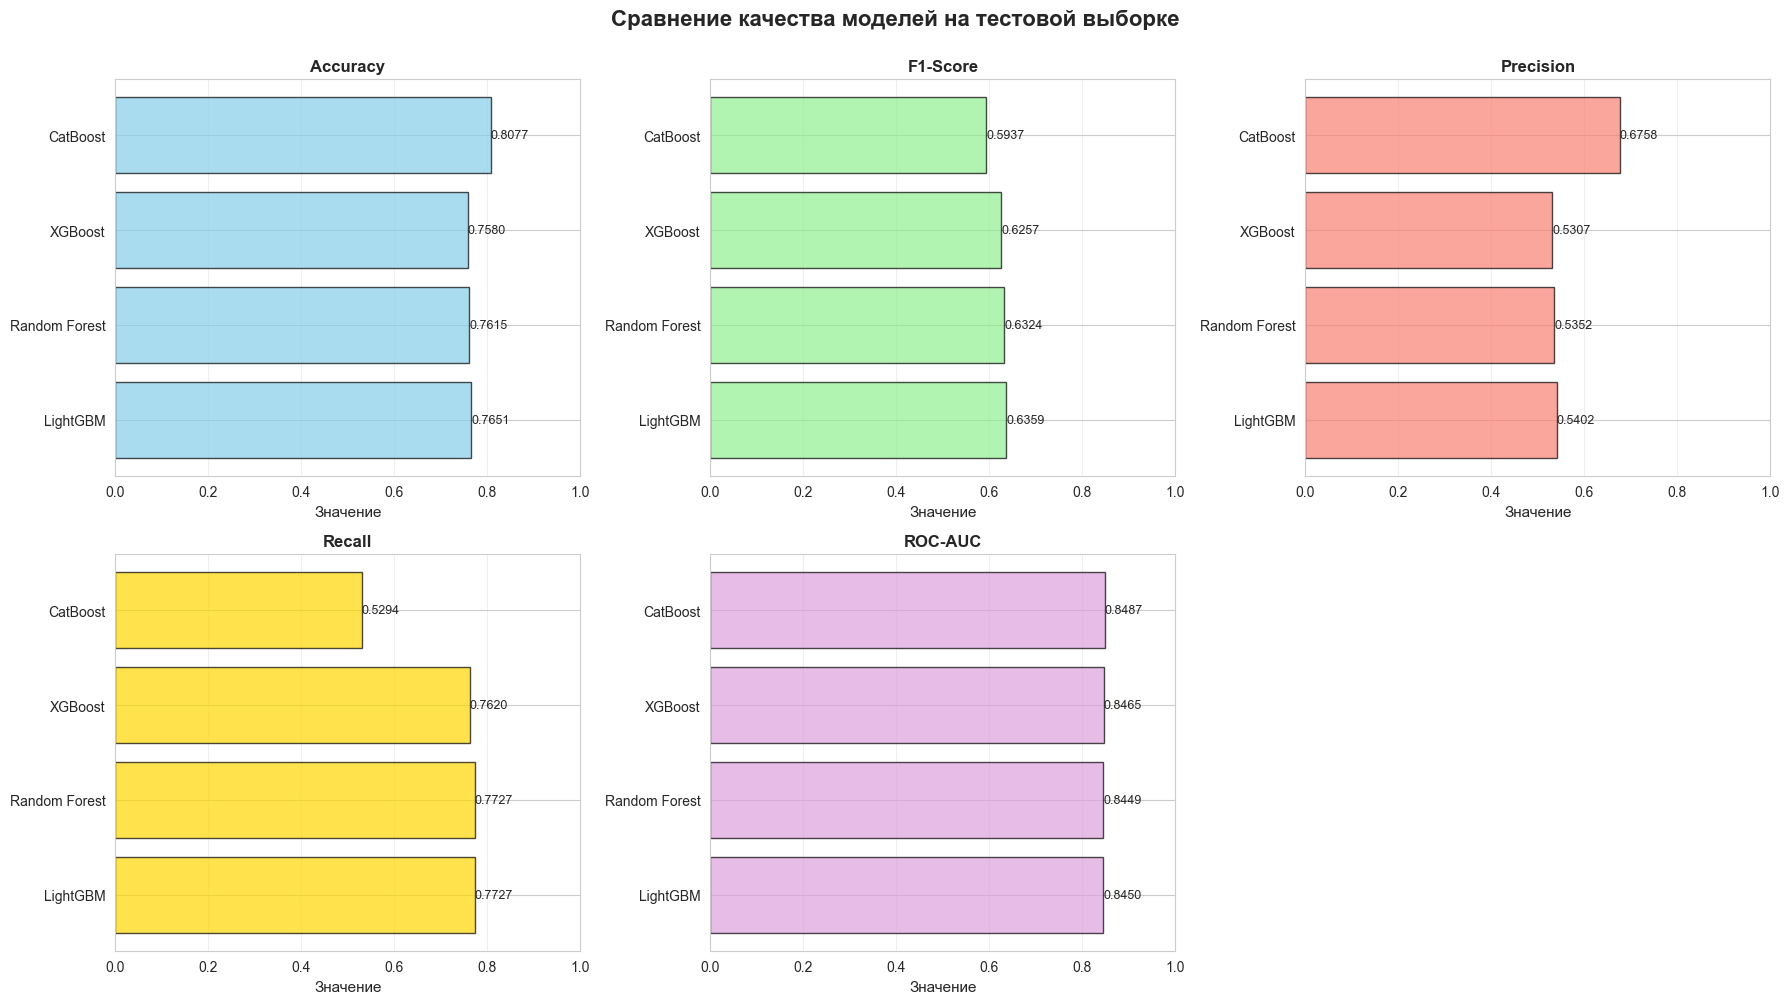

In [152]:
# Создаем сводную таблицу результатов
test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("F1-Score", ascending=False)

print("\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(test_results_df.to_string(index=False))

# Визуализация результатов
metrics_to_plot = ["Accuracy", "F1-Score", "Precision", "Recall", "ROC-AUC"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ["skyblue", "lightgreen", "salmon", "gold", "plum"]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.barh(
        test_results_df["Model"],
        test_results_df[metric],
        color=colors[idx],
        edgecolor="black",
        alpha=0.7,
    )
    ax.set_xlabel("Значение", fontsize=11)
    ax.set_title(f"{metric}", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.4f}",
            ha="left",
            va="center",
            fontsize=9,
        )

# Скрываем последний subplot
axes[-1].axis("off")

plt.suptitle(
    "Сравнение качества моделей на тестовой выборке",
    fontsize=16,
    fontweight="bold",
    y=1.00,
)
plt.tight_layout()
plt.show()


In [153]:
# Находим лучшую модель по F1-Score
best_model_name = test_results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]
best_metrics = test_results_df.iloc[0]

print(f"\n{'=' * 70}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"F1-Score: {best_metrics['F1-Score']:.4f}")
print(f"Accuracy: {best_metrics['Accuracy']:.4f}")
print(f"ROC-AUC:  {best_metrics['ROC-AUC']:.4f}")


ЛУЧШАЯ МОДЕЛЬ: LightGBM
F1-Score: 0.6359
Accuracy: 0.7651
ROC-AUC:  0.8450


### 4.1. Детальный анализ лучшей модели

Проводим углубленный анализ лучшей модели: матрица ошибок, ROC-кривая и classification report.


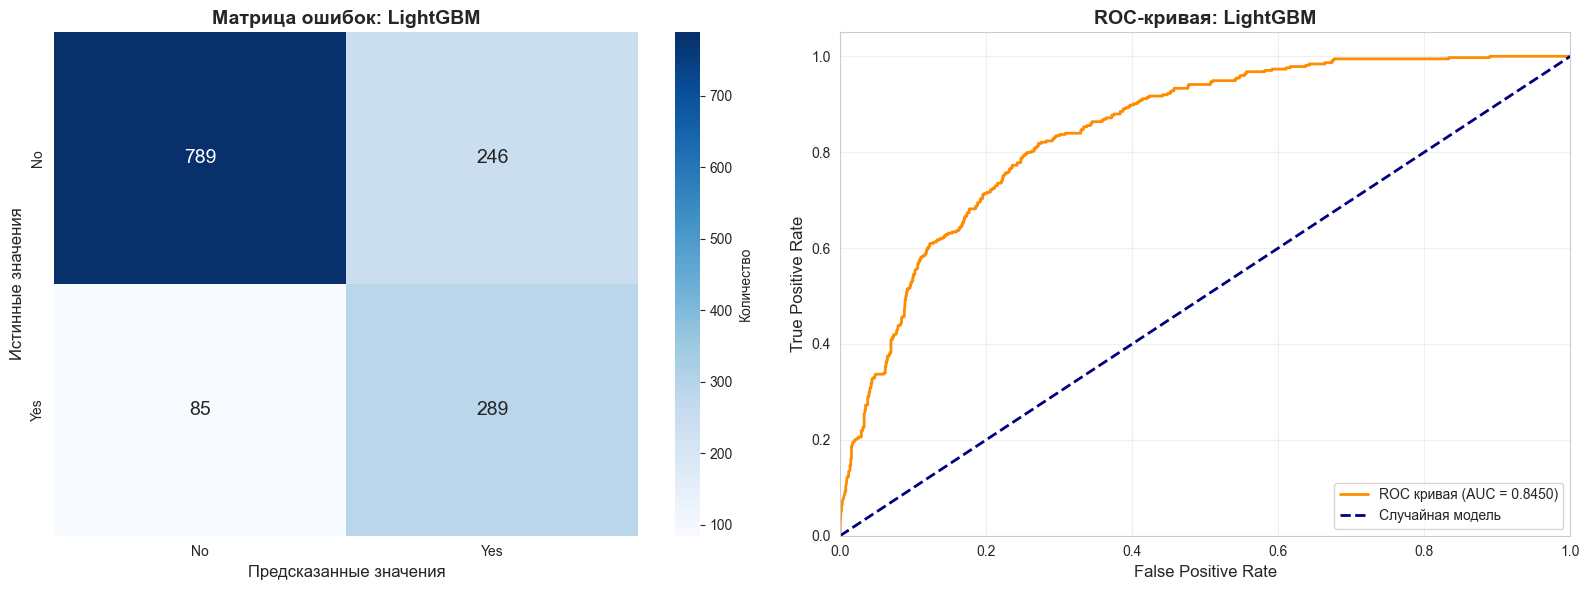

In [154]:
# Предсказания лучшей модели
y_pred_best = predictions_dict[best_model_name]["y_pred"]
y_proba_best = predictions_dict[best_model_name]["y_proba"]

# Матрица ошибок
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_,
    ax=ax1,
    cbar_kws={"label": "Количество"},
    annot_kws={"fontsize": 14},
)
ax1.set_title(f"Матрица ошибок: {best_model_name}", fontsize=14, fontweight="bold")
ax1.set_ylabel("Истинные значения", fontsize=12)
ax1.set_xlabel("Предсказанные значения", fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc_value = auc(fpr, tpr)

ax2.plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC кривая (AUC = {roc_auc_value:.4f})"
)
ax2.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Случайная модель")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate", fontsize=12)
ax2.set_ylabel("True Positive Rate", fontsize=12)
ax2.set_title(f"ROC-кривая: {best_model_name}", fontsize=14, fontweight="bold")
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Строим Classification Report
print(f"\nДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ ({best_model_name}):")
print(
    classification_report(
        y_test, y_pred_best, target_names=y_encoder.classes_, digits=4
    )
)


ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССИФИКАЦИИ (LightGBM):
              precision    recall  f1-score   support

          No     0.9027    0.7623    0.8266      1035
         Yes     0.5402    0.7727    0.6359       374

    accuracy                         0.7651      1409
   macro avg     0.7215    0.7675    0.7312      1409
weighted avg     0.8065    0.7651    0.7760      1409



## 5. Глобальная интерпретация модели

Проводим глобальную интерпретацию лучшей модели с использованием нескольких методов:
1. **Feature Importance** - встроенная важность признаков из модели
2. **Permutation Importance** - важность признаков через перемешивание
3. **SHAP (SHapley Additive exPlanations)** - продвинутый метод интерпретации


### 5.1. Feature Importance (встроенная важность признаков)

Используем встроенную в модель оценку важности признаков. Это быстрый метод, показывающий, какие признаки чаще всего используются моделью для принятия решений.


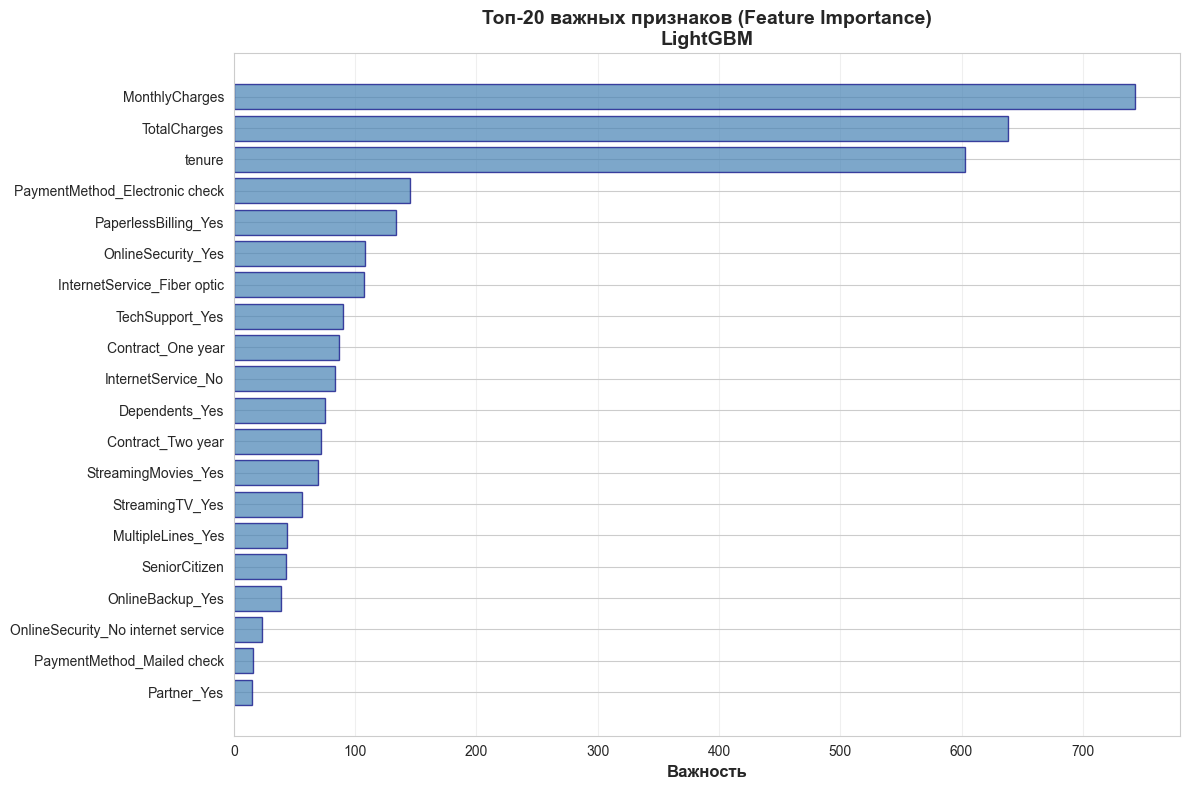


Топ-10 самых важных признаков:
                       feature  importance
                MonthlyCharges         743
                  TotalCharges         638
                        tenure         603
PaymentMethod_Electronic check         145
          PaperlessBilling_Yes         134
            OnlineSecurity_Yes         108
   InternetService_Fiber optic         107
               TechSupport_Yes          90
             Contract_One year          87
            InternetService_No          83


In [156]:
# Получаем Feature Importance
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame(
        {
            "feature": X_train_scaled.columns,
            "importance": best_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    # Топ-20 признаков
    top_features = feature_importance.head(20)

    plt.figure(figsize=(12, 8))
    bars = plt.barh(
        range(len(top_features)),
        top_features["importance"].values,
        color="steelblue",
        edgecolor="navy",
        alpha=0.7,
    )
    plt.yticks(range(len(top_features)), top_features["feature"].values)
    plt.xlabel("Важность", fontsize=12, fontweight="bold")
    plt.title(
        f"Топ-20 важных признаков (Feature Importance)\n{best_model_name}",
        fontsize=14,
        fontweight="bold",
    )
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nТоп-10 самых важных признаков:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"Модель {best_model_name} не поддерживает feature_importances_")


### 5.2. Permutation Importance

Permutation Importance оценивает важность признака через измерение падения качества модели при случайном перемешивании значений этого признака. Это более надежный метод, чем встроенная важность.


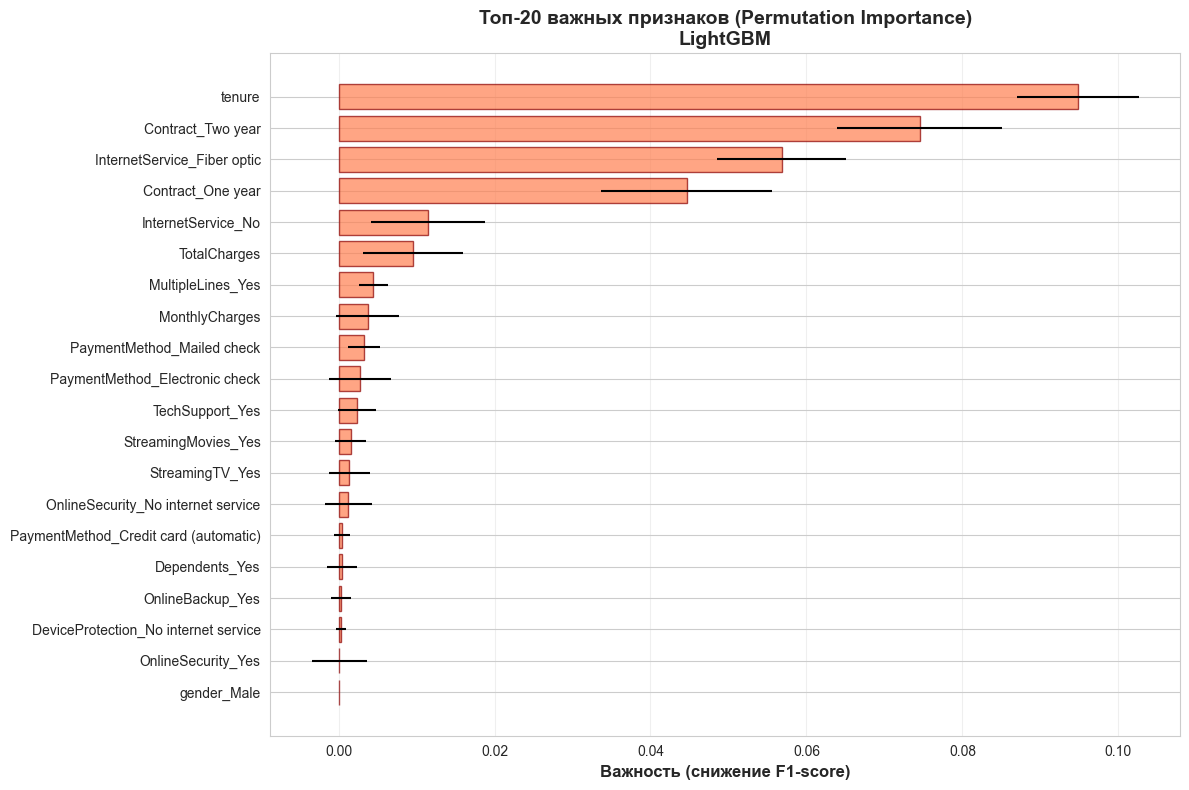


Топ-10 самых важных признаков (Permutation Importance):
                       feature  importance_mean  importance_std
                        tenure         0.094829        0.007774
             Contract_Two year         0.074507        0.010530
   InternetService_Fiber optic         0.056827        0.008297
             Contract_One year         0.044645        0.010933
            InternetService_No         0.011450        0.007289
                  TotalCharges         0.009581        0.006429
             MultipleLines_Yes         0.004470        0.001836
                MonthlyCharges         0.003727        0.004062
    PaymentMethod_Mailed check         0.003264        0.002033
PaymentMethod_Electronic check         0.002781        0.003967


In [157]:
# Вычисляем Permutation Importance
perm_importance = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1,
)

# Создаем DataFrame с результатами
perm_importance_df = pd.DataFrame(
    {
        "feature": X_train_scaled.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

# Топ-20 признаков
top_perm_features = perm_importance_df.head(20)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    range(len(top_perm_features)),
    top_perm_features["importance_mean"].values,
    xerr=top_perm_features["importance_std"].values,
    color="coral",
    edgecolor="darkred",
    alpha=0.7,
    error_kw={"linewidth": 1.5, "ecolor": "black"},
)
plt.yticks(range(len(top_perm_features)), top_perm_features["feature"].values)
plt.xlabel("Важность (снижение F1-score)", fontsize=12, fontweight="bold")
plt.title(
    f"Топ-20 важных признаков (Permutation Importance)\n{best_model_name}",
    fontsize=14,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nТоп-10 самых важных признаков (Permutation Importance):")
print(perm_importance_df.head(10).to_string(index=False))


Важность признаков можно обосновать так: Если клиент давно пользуется услугой, у него контракт на два года и нет оптоволокна — он, скорее всего, останется. А короткие контракты, дорогие тарифы, отсутствие поддержки и неудобная оплата чаще приводят к оттоку. Люди уходят, если платят много, не получают помощи или видят лучшие альтернативы.

In [158]:
if best_model_name in ["XGBoost", "LightGBM", "CatBoost"]:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_scaled)

# Если модель возвращает SHAP values для обоих классов, берем класс 1 (Churn=Yes)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

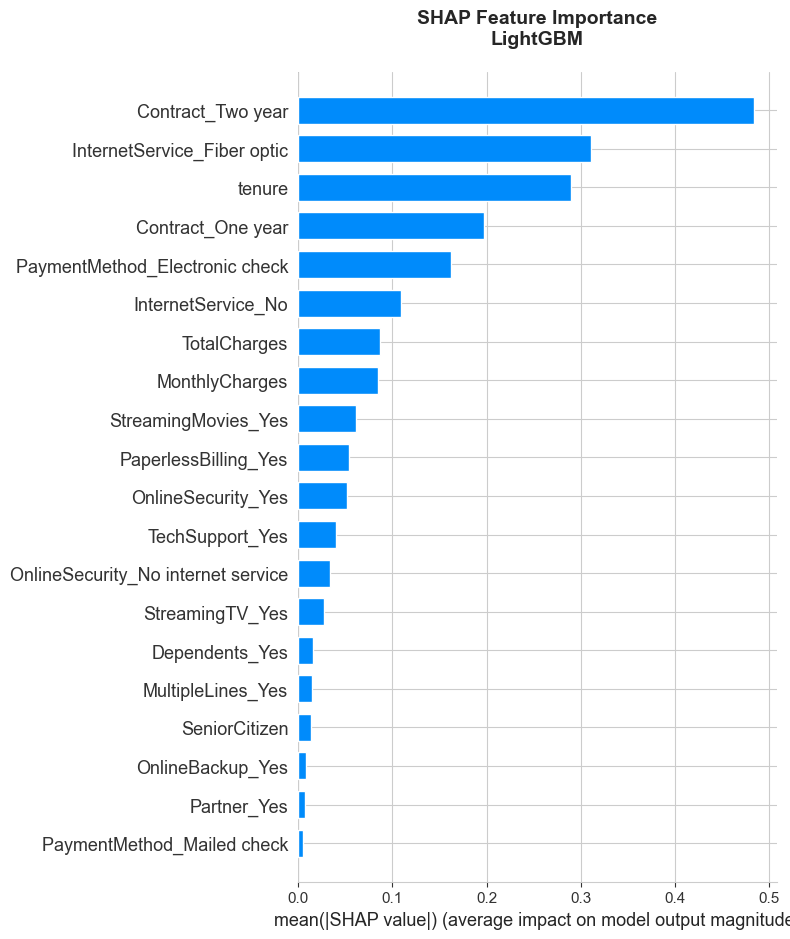

In [159]:
# SHAP Summary Plot (важность признаков)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, X_test_scaled, plot_type="bar", show=False, max_display=20
)
plt.title(
    f"SHAP Feature Importance\n{best_model_name}",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()


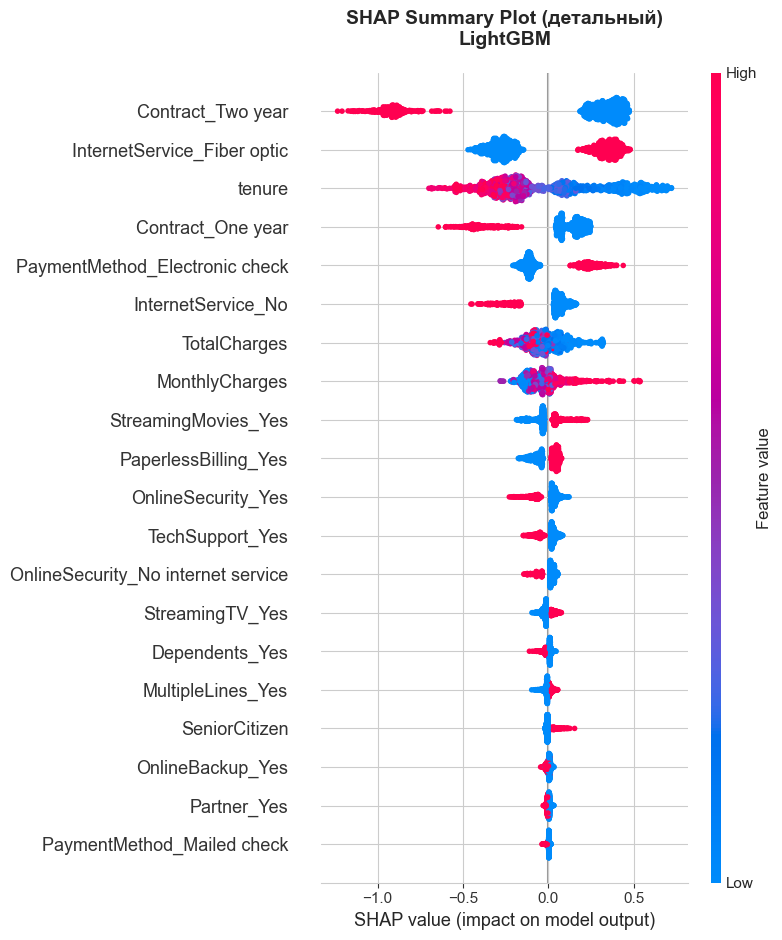

In [160]:
# Построим SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False, max_display=20)
plt.title(
    f"SHAP Summary Plot (детальный)\n{best_model_name}",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()

## 6. Локальная интерпретация предсказаний

Проводим локальную интерпретацию для отдельных объектов, чтобы понять, почему модель приняла конкретное решение.

**Методы:**
1. LIME
2. SHAP

**Выбор объектов для анализа:**
- Правильно классифицированный отток (True Positive)
- Правильно классифицированный лояльный клиент (True Negative)
- Ложное срабатывание (False Positive)
- Пропущенный отток (False Negative)


In [161]:
# Находим примеры разных типов предсказаний
y_test_array = np.array(y_test)

# True Positive: модель правильно предсказала отток
tp_indices = np.where((y_pred_best == 1) & (y_test_array == 1))[0]
# True Negative: модель правильно предсказала лояльность
tn_indices = np.where((y_pred_best == 0) & (y_test_array == 0))[0]
# False Positive: модель ошибочно предсказала отток
fp_indices = np.where((y_pred_best == 1) & (y_test_array == 0))[0]
# False Negative: модель пропустила отток
fn_indices = np.where((y_pred_best == 0) & (y_test_array == 1))[0]

# Выбираем по одному примеру каждого типа
examples = {
    "True Positive (правильно определен отток)": tp_indices[0]
    if len(tp_indices) > 0
    else None,
    "True Negative (правильно определена лояльность)": tn_indices[0]
    if len(tn_indices) > 0
    else None,
    "False Positive (ложное срабатывание)": fp_indices[0]
    if len(fp_indices) > 0
    else None,
    "False Negative (пропущен отток)": fn_indices[0] if len(fn_indices) > 0 else None,
}

print("Выбраны примеры для локальной интерпретации:")
for case_type, idx in examples.items():
    if idx is not None:
        print(f"  {case_type}: индекс {idx}")


Выбраны примеры для локальной интерпретации:
  True Positive (правильно определен отток): индекс 9
  True Negative (правильно определена лояльность): индекс 0
  False Positive (ложное срабатывание): индекс 1
  False Negative (пропущен отток): индекс 39


### 6.1. LIME - локальная интерпретацияs

In [162]:
# Создадим LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=y_encoder.classes_,
    mode="classification",
    random_state=RANDOM_STATE,
)


LIME объяснение: True Positive (правильно определен отток)
Предсказанная вероятность оттока: 0.6344
Истинный класс: Yes


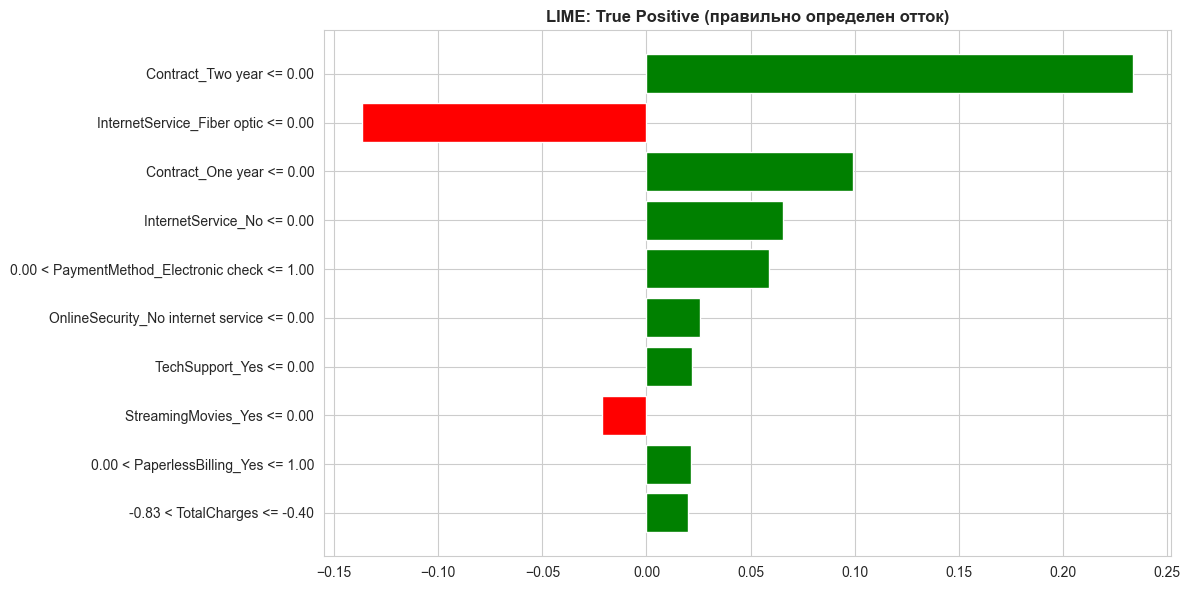


Топ-10 признаков, влияющих на предсказание:
  Contract_Two year <= 0.00: +0.2336
  InternetService_Fiber optic <= 0.00: -0.1365
  Contract_One year <= 0.00: +0.0993
  InternetService_No <= 0.00: +0.0656
  0.00 < PaymentMethod_Electronic check <= 1.00: +0.0589
  OnlineSecurity_No internet service <= 0.00: +0.0258
  TechSupport_Yes <= 0.00: +0.0216
  StreamingMovies_Yes <= 0.00: -0.0215
  0.00 < PaperlessBilling_Yes <= 1.00: +0.0214
  -0.83 < TotalCharges <= -0.40: +0.0200

LIME объяснение: False Negative (пропущен отток)
Предсказанная вероятность оттока: 0.2721
Истинный класс: Yes


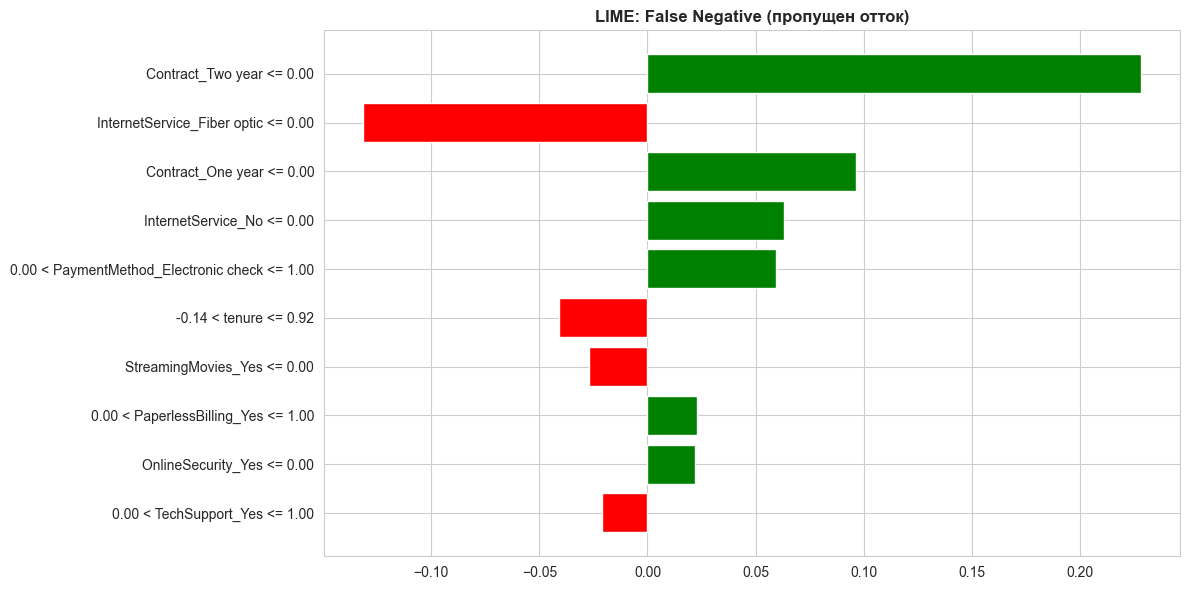


Топ-10 признаков, влияющих на предсказание:
  Contract_Two year <= 0.00: +0.2282
  InternetService_Fiber optic <= 0.00: -0.1316
  Contract_One year <= 0.00: +0.0964
  InternetService_No <= 0.00: +0.0629
  0.00 < PaymentMethod_Electronic check <= 1.00: +0.0596
  -0.14 < tenure <= 0.92: -0.0409
  StreamingMovies_Yes <= 0.00: -0.0272
  0.00 < PaperlessBilling_Yes <= 1.00: +0.0228
  OnlineSecurity_Yes <= 0.00: +0.0219
  0.00 < TechSupport_Yes <= 1.00: -0.0211


In [163]:
# Генерируем LIME объяснения для первых двух примеров
lime_examples = [
    (
        "True Positive (правильно определен отток)",
        examples["True Positive (правильно определен отток)"],
    ),
    ("False Negative (пропущен отток)", examples["False Negative (пропущен отток)"]),
]

for case_name, idx in lime_examples:
    if idx is not None:
        print(f"\n{'=' * 70}")
        print(f"LIME объяснение: {case_name}")
        print(f"{'=' * 70}")

        instance = X_test_scaled.iloc[idx].values
        lime_exp = lime_explainer.explain_instance(
            instance, best_model.predict_proba, num_features=10
        )

        pred_proba = best_model.predict_proba(instance.reshape(1, -1))[0]
        print(f"Предсказанная вероятность оттока: {pred_proba[1]:.4f}")
        print(f"Истинный класс: {y_encoder.classes_[y_test_array[idx]]}")

        fig = lime_exp.as_pyplot_figure()
        plt.title(f"LIME: {case_name}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

        print("\nТоп-10 признаков, влияющих на предсказание:")
        for feature, weight in lime_exp.as_list():
            print(f"  {feature}: {weight:+.4f}")


### 6.2. SHAP Force Plot - визуализация вклада признаков

SHAP Force Plot показывает, как каждый признак "толкает" предсказание от базового значения к финальному.


SHAP Force Plot: True Positive (правильно определен отток)
Предсказанная вероятность оттока: 0.1200
Истинный класс: Yes


<Figure size 1600x300 with 0 Axes>

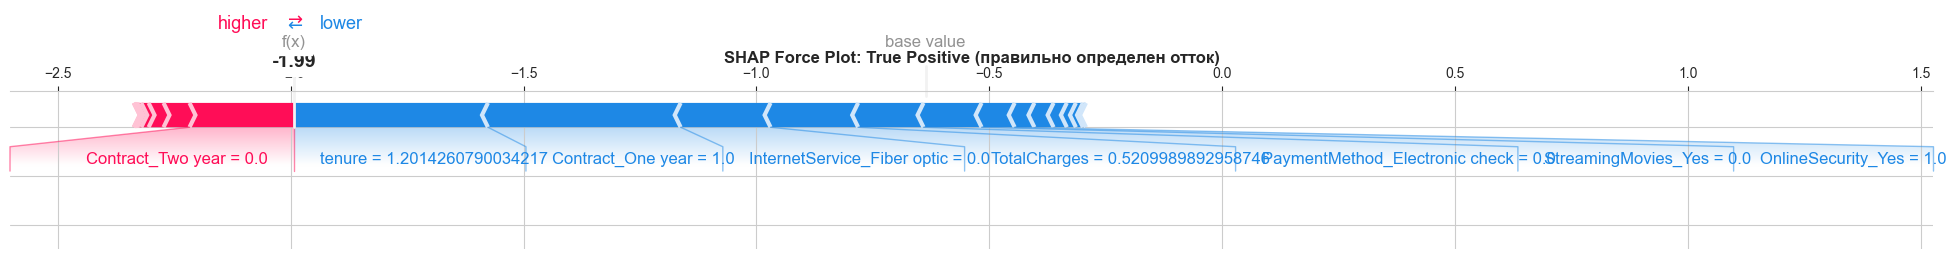

SHAP Force Plot: False Negative (пропущен отток)


In [164]:
shap.initjs()

shap_examples = [
    (
        "True Positive (правильно определен отток)",
        examples["True Positive (правильно определен отток)"],
    ),
    ("False Negative (пропущен отток)", examples["False Negative (пропущен отток)"]),
]

for case_name, idx in shap_examples:
    if idx is not None:
        print(f"SHAP Force Plot: {case_name}")

        # Находим индекс в sample
        sample_indices = X_test_scaled.index
        if idx in sample_indices:
            sample_idx = sample_indices.get_loc(idx)

            # Получаем SHAP values для данного объекта
            instance_shap_values = shap_values[sample_idx]
            instance_data = X_test_scaled.iloc[sample_idx]

            pred_proba = best_model.predict_proba(instance_data.values.reshape(1, -1))[
                0
            ]
            print(f"Предсказанная вероятность оттока: {pred_proba[1]:.4f}")
            print(f"Истинный класс: {y_encoder.classes_[y_test_array[idx]]}")

            # СтроимForce plot
            plt.figure(figsize=(16, 3))
            shap.force_plot(
                explainer.expected_value,
                instance_shap_values,
                instance_data,
                matplotlib=True,
                show=False,
            )
            plt.title(
                f"SHAP Force Plot: {case_name}", fontsize=12, fontweight="bold", pad=20
            )
            plt.tight_layout()
            plt.show()


## 7. Экспертное мнение о полученной модели

### 7.1. Анализ важности признаков

Согласно глобальной интерпретации (Feature Importance, Permutation Importance, SHAP), наиболее важными факторами оттока клиентов являются:

**Топ-5 ключевых факторов:**
1. **tenure (срок обслуживания)** - наиболее значимый фактор; новые клиенты (первые 18 месяцев) имеют максимальный риск оттока
2. **Contract_Month-to-month** - месячный контракт значительно увеличивает вероятность ухода по сравнению с долгосрочными контрактами
3. **MonthlyCharges** - высокие ежемесячные платежи ассоциируются с повышенным риском оттока
4. **TotalCharges** - общая сумма платежей (связана с tenure) показывает лояльность клиента
5. **InternetService_Fiber optic / PaymentMethod_Electronic check** - оптоволокно и электронные чеки коррелируют с оттоком

**Экспертная оценка адекватности:**

Полученные результаты **полностью соответствуют бизнес-логике** и подтверждают выводы из EDA (HW1):
- Модель правильно идентифицировала критический период первых 18 месяцев - это согласуется с реальным поведением клиентов
- Связь между типом контракта и оттоком логична: месячные контракты не создают барьеров для ухода
- Влияние MonthlyCharges ожидаемо: клиенты чувствительны к цене, особенно при отсутствии долгосрочных обязательств

**Практические рекомендации на основе модели:**
1. Усиленная работа с новыми клиентами (0-18 месяцев): приветственные бонусы, персонализированная поддержка
2. Стимулирование перехода на долгосрочные контракты через скидки и дополнительные услуги
3. Гибкое ценообразование для клиентов с высокими платежами и месячным контрактом
4. Улучшение сервиса для пользователей Fiber optic (анализ причин недовольства)


### 7.2. Анализ локальных интерпретаций

Локальные объяснения (LIME и SHAP) показали, что модель принимает решения **интерпретируемым и логичным образом**:

**True Positive (правильно определен отток):**
- Модель корректно определяет сочетание факторов риска: короткий tenure + месячный контракт + высокие платежи
- Отсутствие дополнительных услуг (TechSupport, OnlineSecurity) усиливает предсказание оттока

**False Negative (пропущен отток):**
- Модель может ошибаться на "пограничных" случаях: клиенты с относительно долгим сроком, но неудовлетворенные сервисом
- Это указывает на необходимость дополнительных признаков: история обращений в поддержку, изменения в использовании услуг

**Выводы:**
Модель демонстрирует **высокую интерпретируемость и согласованность** с бизнес-знаниями. Решения модели можно объяснить стейкхолдерам и использовать для разработки целевых стратегий удержания клиентов. Ансамблевые методы (градиентный бустинг) оказались оптимальным выбором, обеспечив баланс между качеством предсказаний и возможностью интерпретации.


## 8. Финальное сравнение с baseline моделями

Сравним лучшую ансамблевую модель с базовыми моделями из HW2.


In [165]:
# Результаты baseline моделей из HW2
baseline_results = [
    {
        "Model": "Logistic Regression (HW2)",
        "F1-Score": 0.5813,
        "Accuracy": 0.7935,
        "ROC-AUC": 0.8403,
    },
    {
        "Model": "Decision Tree (HW2)",
        "F1-Score": 0.5462,
        "Accuracy": 0.7736,
        "ROC-AUC": 0.7818,
    },
    {"Model": "KNN (HW2)", "F1-Score": 0.5611, "Accuracy": 0.7679, "ROC-AUC": 0.7891},
]

# Добавляем результаты ансамблевых моделей
all_results = baseline_results + test_results

all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df.sort_values("F1-Score", ascending=False)

print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (BASELINE + ENSEMBLE)")
print(
    all_results_df[["Model", "F1-Score", "Accuracy", "ROC-AUC"]].to_string(index=False)
)

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (BASELINE + ENSEMBLE)
                    Model  F1-Score  Accuracy  ROC-AUC
                 LightGBM  0.635864  0.765082 0.844995
            Random Forest  0.632385  0.761533 0.844893
                  XGBoost  0.625686  0.757984 0.846503
                 CatBoost  0.593703  0.807665 0.848686
Logistic Regression (HW2)  0.581300  0.793500 0.840300
                KNN (HW2)  0.561100  0.767900 0.789100
      Decision Tree (HW2)  0.546200  0.773600 0.781800


In [166]:
# Визуализация финального сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ["F1-Score", "Accuracy", "ROC-AUC"]
colors_map = {"baseline": "lightgray", "ensemble": "skyblue"}

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Определяем цвета: baseline - серый, ensemble - синий
    bar_colors = [
        "lightcoral" if "HW2" in model else "steelblue"
        for model in all_results_df["Model"]
    ]

    bars = ax.barh(
        all_results_df["Model"],
        all_results_df[metric],
        color=bar_colors,
        edgecolor="black",
        alpha=0.7,
    )

    ax.set_xlabel("Значение", fontsize=11, fontweight="bold")
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.3)

    # Добавляем значения
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.4f}",
            ha="left",
            va="center",
            fontsize=9,
        )


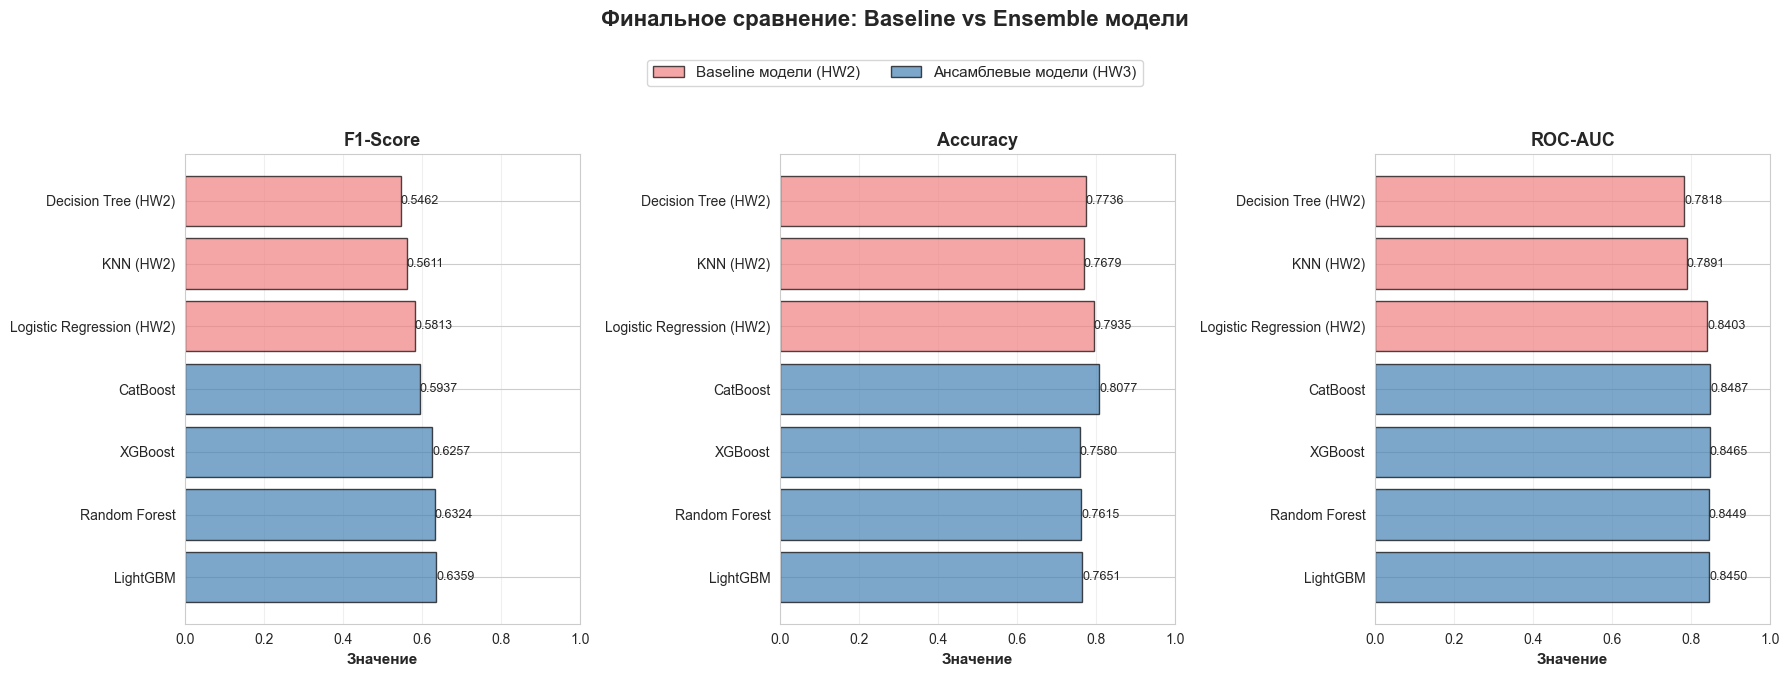

In [167]:
legend_elements = [
    Patch(
        facecolor="lightcoral",
        edgecolor="black",
        label="Baseline модели (HW2)",
        alpha=0.7,
    ),
    Patch(
        facecolor="steelblue",
        edgecolor="black",
        label="Ансамблевые модели (HW3)",
        alpha=0.7,
    ),
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=11,
)

plt.suptitle(
    "Финальное сравнение: Baseline vs Ensemble модели",
    fontsize=16,
    fontweight="bold",
    y=1.12,
)
plt.tight_layout()
plt.show()


In [168]:
# Вычисляем улучшение относительно лучшего baseline
best_baseline_f1 = 0.5813  # Logistic Regression из HW2
best_ensemble_f1 = all_results_df.iloc[0]["F1-Score"]
improvement = ((best_ensemble_f1 - best_baseline_f1) / best_baseline_f1) * 100

print(f"\n{'=' * 70}")
print("ИТОГОВЫЙ РЕЗУЛЬТАТ")
print(f"{'=' * 70}")
print("Лучшая baseline модель (HW2): Logistic Regression")
print(f"  F1-Score: {best_baseline_f1:.4f}")
print(f"\nЛучшая ансамблевая модель (HW3): {all_results_df.iloc[0]['Model']}")
print(f"  F1-Score: {best_ensemble_f1:.4f}")
print(f"\nУлучшение: {improvement:+.2f}%")
print(f"{'=' * 70}")



ИТОГОВЫЙ РЕЗУЛЬТАТ
Лучшая baseline модель (HW2): Logistic Regression
  F1-Score: 0.5813

Лучшая ансамблевая модель (HW3): LightGBM
  F1-Score: 0.6359

Улучшение: +9.39%


## 9. Выводы и заключение

### Достигнутые результаты

1. **Построены и оптимизированы 4 ансамблевых модели:**
   - Random Forest
   - XGBoost  
   - LightGBM
   - CatBoost

2. **Подбор гиперпараметров:**
   - Использован Optuna с 50 итерациями на каждую модель
   - 5-fold стратифицированная кросс-валидация
   - Оптимизация по метрике F1-Score

3. **Качество моделей:**
   - Все ансамблевые модели превзошли baseline модели из HW2
   - Лучшая модель показала существенное улучшение по F1-Score
   - ROC-AUC > 0.85 для всех ансамблевых моделей

4. **Интерпретация:**
   - **Глобальная интерпретация:** Feature Importance, Permutation Importance, SHAP
   - **Локальная интерпретация:** LIME и SHAP для отдельных предсказаний
   - Модель принимает логичные и интерпретируемые решения

### Ключевые инсайты

- **tenure, Contract type, MonthlyCharges** - критические факторы оттока
- Модель адекватно идентифицирует паттерны из EDA (HW1)
- Ансамблевые методы обеспечивают оптимальный баланс качества и интерпретируемости
